In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [17]:
XX = 1

with open(f'data/dane{XX}.txt', 'r') as file:
    data = file.readlines()

x_data, y_data = zip(*[
    map(float, line.split())
    for line in data
])

scaler = MinMaxScaler()
x_data_normalized = scaler.fit_transform(np.array(x_data).reshape(-1, 1))
y_data_normalized = scaler.fit_transform(np.array(y_data).reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(x_data_normalized, y_data_normalized, test_size=0.2,
                                                    random_state=42)

In [18]:
class NeuralNetworkCustom:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

        self.weights_input_hidden = np.random.randn(self.input_size, self.hidden_size)
        self.weights_hidden_output = np.random.randn(self.hidden_size, self.output_size)

        self.bias_hidden = np.zeros(self.hidden_size)
        self.bias_output = np.zeros(self.output_size)

        self.history_mse = []
        self.history_r2 = []

    def tanh(self, x):
        return np.tanh(x)

    def tanh_derivative(self, x):
        return 1.0 - np.tanh(x) ** 2

    def relu(self, x):
        return np.maximum(0,1*x)

    def relu_derivative(self, x):
        return np.where(x > 0, 1, np.where(x < 0, 0, 0.5))

    def forward_tanh(self, X):
        hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        hidden_input = self.tanh(hidden_input)

        output_input = np.dot(hidden_input, self.weights_hidden_output) + self.bias_output
        return self.tanh(output_input)

    def forward_relu(self, X):
        hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        hidden_input = self.relu(hidden_input)

        output_input = np.dot(hidden_input, self.weights_hidden_output) + self.bias_output
        return self.relu(output_input)

    def backprop_tanh(self, X, y, output, learning_rate, reg_lambda):
        output_error = y - output

        hidden_output = self.tanh(np.dot(X, self.weights_input_hidden) + self.bias_hidden)
        gradient_hidden_output = np.dot(hidden_output.T, output_error)

        hidden_error = np.dot(output_error, self.weights_hidden_output.T)
        hidden_error *= self.tanh_derivative(hidden_output)

        gradient_input_hidden = np.dot(X.T, hidden_error)

        self.weights_hidden_output += (gradient_hidden_output - reg_lambda * self.weights_hidden_output) * learning_rate
        self.weights_input_hidden += (gradient_input_hidden - reg_lambda * self.weights_input_hidden) * learning_rate

        self.bias_output += np.sum(output_error, axis=0) * learning_rate
        self.bias_hidden += np.sum(hidden_error, axis=0) * learning_rate

    def backprop_relu(self, X, y, output, learning_rate, reg_lambda):
        output_error = y - output

        hidden_output = self.relu(np.dot(X, self.weights_input_hidden) + self.bias_hidden)
        gradient_hidden_output = np.dot(hidden_output.T, output_error)

        hidden_error = np.dot(output_error, self.weights_hidden_output.T)
        hidden_error *= self.relu_derivative(hidden_output)

        gradient_input_hidden = np.dot(X.T, hidden_error)

        self.weights_hidden_output += (gradient_hidden_output - reg_lambda * self.weights_hidden_output) * learning_rate
        self.weights_input_hidden += (gradient_input_hidden - reg_lambda * self.weights_input_hidden) * learning_rate

        self.bias_output += np.sum(output_error, axis=0) * learning_rate
        self.bias_hidden += np.sum(hidden_error, axis=0) * learning_rate

    def train_backprop_tanh(self, X, y, epochs, learning_rate, reg_lambda):
        for epoch in range(1, epochs):
            output = self.forward_tanh(X)
            self.backprop_tanh(X, y, output, learning_rate, reg_lambda)

            mse = mean_squared_error(y, output)
            r2 = r2_score(y, output)

            self.history_mse.append(mse)
            self.history_r2.append(r2)

    def train_backprop_relu(self, X, y, epochs, learning_rate, reg_lambda):
        for epoch in range(1, epochs):
            output = self.forward_relu(X)
            self.backprop_relu(X, y, output, learning_rate, reg_lambda)

            mse = mean_squared_error(y, output)
            r2 = r2_score(y, output)

            self.history_mse.append(mse)
            self.history_r2.append(r2)

    def train_stochastic(self, X, y, epochs, learning_rate, reg_lambda):
        n = X.shape[0]
        for epoch in range(epochs):
            for i in range(n):
                xi = X[i].reshape(1, -1)
                yi = y[i].reshape(1, -1)

                output = self.forward_tanh(xi)
                self.backprop_tanh(xi, yi, output, learning_rate, reg_lambda)

            output_full = self.forward_tanh(X)

            mse = mean_squared_error(y, output_full)
            r2 = r2_score(y, output_full)

            self.history_mse.append(mse)
            self.history_r2.append(r2)

    def predict_tanh(self, X):
        y_pred = self.forward_tanh(X)
        return y_pred

    def predict_relu(self, X):
        y_pred = self.forward_relu(X)
        return y_pred

In [19]:
input_size = 1
hidden_size = 100
output_size = 1
epochs = 2000
learning_rate = 0.02
reg_lambda = 0.01

In [20]:
nn = NeuralNetworkCustom(input_size, hidden_size, output_size)
nn.train_backprop_tanh(X_train, y_train, epochs, learning_rate, reg_lambda)

In [21]:
def assess_performance(hidden_size, epochs, learning_rate, reg_lambda):
    nn = NeuralNetworkCustom(1, hidden_size, 1)

    print("\nTraining...")
    nn.train_backprop_tanh(X_train, y_train, epochs, learning_rate, reg_lambda)

    y_train_pred = nn.predict_tanh(X_train)
    y_test_pred = nn.predict_tanh(X_test)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"FINAL RESULTS (epochs={epochs}, hidden={hidden_size}, lr={learning_rate}, reg={reg_lambda})")
    print(f"TRAIN → RMSE: {mse_train:.4f}, R2: {r2_train:.4f}")
    print(f"TEST  → RMSE: {mse_test:.4f}, R2: {r2_test:.4f}")

    diff = abs(r2_train - r2_test)
    if r2_train < 0.7 and r2_test < 0.7:
        print("Model: UNDERFITTING")
    elif diff < 0.05:
        print("Model: GOOD FIT")
    else:
        print("Model: OVERFITTING")

In [22]:
epochs_list = [100, 500, 1000]
hidden_sizes = [10, 50, 100]
learning_rates = [0.001, 0.01, 0.05]

for epoch in epochs_list:
    for hidden_size in hidden_sizes:
        for lr in learning_rates:
            assess_performance(hidden_size, epoch, lr, 0.01)




Training...
FINAL RESULTS (epochs=100, hidden=10, lr=0.001, reg=0.01)
TRAIN → RMSE: 0.0893, R2: -0.0997
TEST  → RMSE: 0.1710, R2: -0.4402
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=10, lr=0.01, reg=0.01)
TRAIN → RMSE: 0.0700, R2: 0.1377
TEST  → RMSE: 0.1302, R2: -0.0962
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=10, lr=0.05, reg=0.01)
TRAIN → RMSE: 0.0741, R2: 0.0876
TEST  → RMSE: 0.1321, R2: -0.1126
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=50, lr=0.001, reg=0.01)
TRAIN → RMSE: 0.0692, R2: 0.1474
TEST  → RMSE: 0.1256, R2: -0.0581
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=50, lr=0.01, reg=0.01)
TRAIN → RMSE: 0.1420, R2: -0.7486
TEST  → RMSE: 0.1551, R2: -0.3066
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=50, lr=0.05, reg=0.01)
TRAIN → RMSE: 0.4894, R2: -5.0248
TEST  → RMSE: 0.5057, R2: -3.2584
Model: UNDERFITTING

Training...
FINAL RESULTS (epochs=100, hidden=100, l

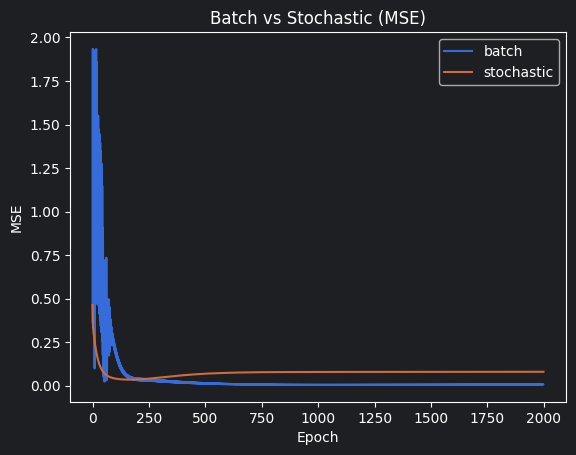

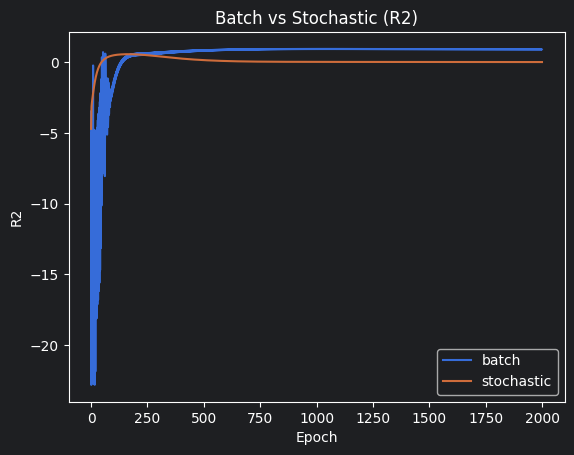

In [27]:
nn_batch = NeuralNetworkCustom(1, 100, 1)
nn_batch.train_backprop_tanh(X_train, y_train, 2000, 0.01, 0.01)

nn_stochastic = NeuralNetworkCustom(1, 100, 1)
nn_stochastic.train_stochastic(X_train, y_train, 2000, 0.01, 0.01)

plt.plot(nn_batch.history_mse, label="batch")
plt.plot(nn_stochastic.history_mse, label="stochastic")

plt.legend()
plt.title("Batch vs Stochastic (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

plt.plot(nn_batch.history_r2, label="batch")
plt.plot(nn_stochastic.history_r2, label="stochastic")

plt.legend()
plt.title("Batch vs Stochastic (R2)")
plt.xlabel("Epoch")
plt.ylabel("R2")
plt.show()

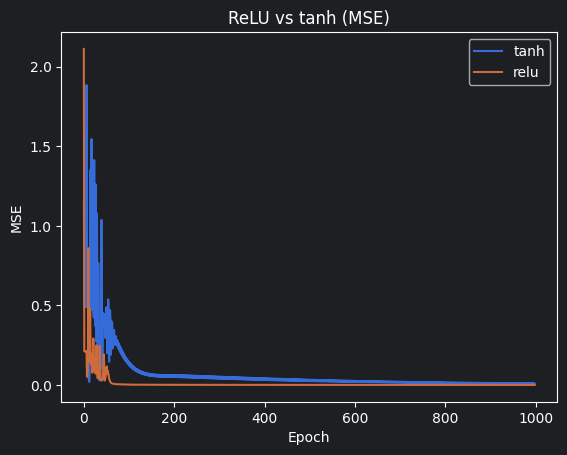

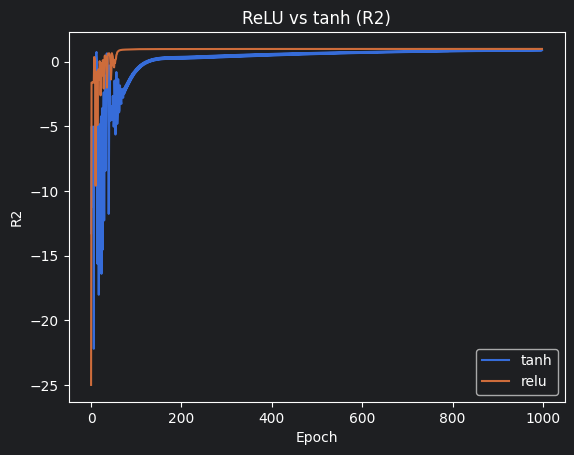

In [26]:
nn_tanh = NeuralNetworkCustom(1, 50, 1)
nn_tanh.train_backprop_tanh(X_train, y_train, 1000, 0.01, 0.01)

nn_relu = NeuralNetworkCustom(1, 50, 1)
nn_relu.train_backprop_relu(X_train, y_train, 1000, 0.01, 0.01)

plt.plot(nn_tanh.history_mse, label="tanh")
plt.plot(nn_relu.history_mse, label="relu")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("ReLU vs tanh (MSE)")
plt.legend()
plt.show()

plt.plot(nn_tanh.history_r2, label="tanh")
plt.plot(nn_relu.history_r2, label="relu")

plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title("ReLU vs tanh (R2)")
plt.legend()
plt.show()